# Final test diagnostics

This notebook prepares additional diagnostics for thesis section 3.5.

It does not repeat walk-forward validation or hyperparameter search. It reads final verification reports from `notebooks/outputs-three-classes-rich-price/*_final_test_verification.csv`, then keeps only two rows per model at most:

- the best configuration selected by test `balanced_accuracy` from that model's final verification CSV,
- the corresponding `price + volume` baseline configuration for the same model.

The selected configurations are refit on `train + validation`, predicted on the held-out test set, and used to calculate:

- accuracy, balanced accuracy, precision, recall and F1,
- metric changes versus the `price + volume` baseline within the same model family,
- per-class precision, recall and F1 for `down`, `neutral` and `up`,
- confusion matrices as CSV files and PNG heatmaps.


In [1]:
from __future__ import annotations

from pathlib import Path
import ast
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

try:
    from xgboost import XGBClassifier
except Exception as exc:
    XGBClassifier = None
    XGBOOST_IMPORT_ERROR = exc

try:
    from lightgbm import LGBMClassifier
except Exception as exc:
    LGBMClassifier = None
    LIGHTGBM_IMPORT_ERROR = exc

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 260)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

sns.set_theme(style="whitegrid", context="notebook")


## Configuration

The notebook uses the same dataset, split, feature builder and final report directory as the
rich-price three-class experiment.


In [2]:
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "data" / "datasets").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebook_utils.experiment_config import build_default_config
from notebook_utils.feature_set_grid_builder import FeatureFrameBuilder, FeatureSetGridBuilder
from notebook_utils.metrics import ClassificationMetrics
from notebook_utils.split_utils import make_split_dates, subset_by_dates

CONFIG = build_default_config(PROJECT_ROOT)
CLASS_VALUES = list(ClassificationMetrics.CLASS_VALUES)
CLASS_LABELS = ClassificationMetrics.CLASS_LABELS

REPORT_DIR = PROJECT_ROOT / "notebooks" / "outputs-three-classes-rich-price"
DIAGNOSTIC_OUTPUT_DIR = REPORT_DIR / "test-diagnostics"
CONFUSION_PLOT_DIR = DIAGNOSTIC_OUTPUT_DIR / "confusion-matrices"

REPORT_GLOB = "*_final_test_verification.csv"
MODEL_FILTER = None
FEATURE_FAMILY_FILTER = None

DIAGNOSTIC_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONFUSION_PLOT_DIR.mkdir(parents=True, exist_ok=True)

feature_grid = FeatureSetGridBuilder.build(max_features_per_model=CONFIG["max_features_per_model"])
FEATURE_SETS = feature_grid.feature_sets

CONFIG


{'dataset_path': WindowsPath('C:/Users/user/OneDrive/Documents/magisterka/praca magisterska/code/data/datasets/stock_panel_nine_tickers_session_aligned_full_history_rich_price_adjusted_google_score_raw.csv'),
 'excluded_tickers': ['NFLX'],
 'neutral_band': 0.005,
 'test_size': 0.25,
 'validation_fraction_within_pretest': 0.25,
 'min_validation_dates': 20,
 'gap_days': 1,
 'random_state': 42,
 'selection_metric': 'balanced_accuracy',
 'primary_validation_metric': 'balanced_accuracy',
 'walk_forward_folds': 4,
 'walk_forward_validation_dates': 80,
 'walk_forward_min_train_dates': 252,
 'max_features_per_model': 14,
 'early_stopping_fraction': 0.2,
 'min_early_stopping_dates': 40,
 'min_fit_dates': 120}

## Data split reconstruction

Final models are refit on `train + validation` and evaluated on the unchanged held-out test set.


In [3]:
raw_df = pd.read_csv(CONFIG["dataset_path"], parse_dates=["date"])
raw_df = raw_df[~raw_df["ticker"].isin(CONFIG["excluded_tickers"])].copy()
raw_df = raw_df.sort_values(["ticker", "date"]).reset_index(drop=True)

feature_df = FeatureFrameBuilder.build_feature_frame(raw_df, neutral_band=CONFIG["neutral_band"])

train_dates, validation_dates, test_dates = make_split_dates(
    feature_df,
    test_size=CONFIG["test_size"],
    validation_fraction_within_pretest=CONFIG["validation_fraction_within_pretest"],
    min_validation_dates=CONFIG["min_validation_dates"],
    gap_days=CONFIG["gap_days"],
)

modeled_df = feature_df[feature_df["target"].isin(CLASS_VALUES)].copy()
modeled_df["target"] = modeled_df["target"].astype(int)

train_df = subset_by_dates(modeled_df, train_dates)
validation_df = subset_by_dates(modeled_df, validation_dates)
test_df = subset_by_dates(modeled_df, test_dates)
train_validation_df = subset_by_dates(modeled_df, list(train_dates) + list(validation_dates))

split_summary_df = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(frame),
            "dates": frame["date"].nunique(),
            "date_min": frame["date"].min(),
            "date_max": frame["date"].max(),
            "down": int(frame["target"].eq(0).sum()),
            "neutral": int(frame["target"].eq(1).sum()),
            "up": int(frame["target"].eq(2).sum()),
        }
        for name, frame in [("train", train_df), ("validation", validation_df), ("test", test_df)]
    ]
)

split_summary_df


,split,rows,dates,date_min,date_max,down,neutral,up
0,train,5632,704,2021-01-04,2023-10-19,2177,1175,2280
1,validation,1880,235,2023-10-23,2024-09-27,615,456,809
2,test,2504,313,2024-10-01,2025-12-30,893,618,993


## Selected final configurations

The final verification CSVs contain one row per feature family for each model. To keep the diagnostics focused, this notebook selects only the best test configuration per model and the `price + volume` baseline for the same model.

The best configuration is selected from each CSV by `test_balanced_accuracy`, with `test_f1_score` and `test_accuracy` used only as tie-breakers.


In [4]:

report_paths = sorted(REPORT_DIR.glob(REPORT_GLOB))
if not report_paths:
    raise FileNotFoundError(f"No final verification reports found in {REPORT_DIR}")

report_frames = []
for path in report_paths:
    model_name = path.name.replace("_final_test_verification.csv", "")
    if MODEL_FILTER is not None and model_name not in MODEL_FILTER:
        continue
    frame = pd.read_csv(path)
    frame.insert(0, "model_name", model_name)
    frame.insert(1, "report_path", str(path))
    report_frames.append(frame)

all_report_rows_df = pd.concat(report_frames, ignore_index=True)
if FEATURE_FAMILY_FILTER is not None:
    all_report_rows_df = all_report_rows_df[
        all_report_rows_df["feature_family"].isin(FEATURE_FAMILY_FILTER)
    ].copy()

sort_columns = [
    "model_name",
    "test_balanced_accuracy",
    "test_f1_score",
    "test_accuracy",
    "validation_balanced_accuracy",
    "feature_set",
]

best_test_configs_df = (
    all_report_rows_df
    .sort_values(sort_columns, ascending=[True, False, False, False, False, True])
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)
best_test_configs_df["diagnostic_role"] = "best_test_config"

price_volume_baseline_df = (
    all_report_rows_df[all_report_rows_df["feature_family"].eq("price + volume")]
    .sort_values(sort_columns, ascending=[True, False, False, False, False, True])
    .groupby("model_name", as_index=False)
    .head(1)
    .copy()
)
price_volume_baseline_df["diagnostic_role"] = "price_volume_baseline"

# The baseline rows are refitted only to compute deltas versus price + volume.
# The exported final outputs below keep one best test configuration per model.
selected_configs_df = pd.concat([best_test_configs_df, price_volume_baseline_df], ignore_index=True)
identity_columns = ["model_name", "feature_set", "param_set"]
role_df = (
    selected_configs_df
    .groupby(identity_columns)["diagnostic_role"]
    .apply(lambda values: "+".join(dict.fromkeys(values)))
    .reset_index()
)
selected_configs_df = (
    selected_configs_df
    .drop(columns=["diagnostic_role"])
    .drop_duplicates(identity_columns)
    .merge(role_df, on=identity_columns, how="left")
    .sort_values(["model_name", "diagnostic_role", "test_balanced_accuracy"], ascending=[True, True, False])
    .reset_index(drop=True)
)

missing_feature_sets = sorted(set(selected_configs_df["feature_set"]).difference(FEATURE_SETS))
if missing_feature_sets:
    raise KeyError(f"Feature sets missing from FeatureSetGridBuilder: {missing_feature_sets}")

print(f"Reports loaded: {len(report_frames)}")
print(f"All final verification rows read: {len(all_report_rows_df)}")
print(f"Best test configurations selected for final outputs: {len(best_test_configs_df)}")
print(f"Price + volume baselines selected only for deltas: {len(price_volume_baseline_df)}")
print(f"Configurations to refit internally: {len(selected_configs_df)}")

best_test_configs_df[
    [
        "model_name",
        "diagnostic_role",
        "feature_family",
        "feature_set",
        "n_features",
        "param_set",
        "validation_balanced_accuracy",
        "test_accuracy",
        "test_balanced_accuracy",
        "test_f1_score",
    ]
]


Reports loaded: 6
All final verification rows read: 150
Best test configurations selected for final outputs: 6
Price + volume baselines selected only for deltas: 6
Configurations to refit internally: 12


,model_name,diagnostic_role,feature_family,feature_set,n_features,param_set,validation_balanced_accuracy,test_accuracy,test_balanced_accuracy,test_f1_score
0,lightgbm,best_test_config,price + volume + GDELT sentiment + Reddit atte...,Model O - price + volume + GDELT sentiment + R...,11,lgbm_250_leaves31_depth4_lr0p02_sub0p7_col0p7_...,0.3713,0.3750,0.3997,0.3741
25,logistic_regression,best_test_config,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | cl...,13,logreg_l2_C0p1_balanced_lbfgs,0.3726,0.3534,0.3935,0.3451
50,neutral_net,best_test_config,price + volume + GDELT sentiment lags,Model Q - price + volume + GDELT sentiment lag...,12,mlp_32_alpha1e-3_lr1e-3_b256,0.3467,0.4002,0.3672,0.3575
75,random_forest,best_test_config,price + volume + GDELT sentiment + Reddit + Go...,Model P - price + volume + GDELT sentiment + R...,12,rf_300_depth6_leaf20_mf0p5_balanced_subsample,0.3586,0.3766,0.4066,0.3737
100,svm,best_test_config,price + volume + GDELT + Google,Model H - price + volume + GDELT + Google | zs...,12,rbf_C0p1_gammascale_balanced,0.3669,0.3682,0.4061,0.3599
125,xgboost,best_test_config,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | zs...,13,xgb_250_depth4_lr0p02_sub0p7_col0p7_child30_ga...,0.3632,0.3874,0.4130,0.3861


## Model reconstruction helpers


In [5]:
def is_missing_value(value: object) -> bool:
    if value is None:
        return True
    try:
        if pd.isna(value):
            return True
    except TypeError:
        pass
    return str(value).strip().lower() in {"", "none", "nan", "null"}


def optional_str(value: object) -> str | None:
    return None if is_missing_value(value) else str(value)


def optional_float(value: object) -> float | None:
    return None if is_missing_value(value) else float(value)


def optional_int(value: object) -> int | None:
    return None if is_missing_value(value) else int(float(value))


def parse_bool(value: object) -> bool:
    if isinstance(value, bool):
        return value
    return str(value).strip().lower() in {"true", "1", "yes"}


def parse_max_features(value: object) -> str | float | None:
    if is_missing_value(value):
        return None
    text = str(value).strip()
    if text in {"sqrt", "log2"}:
        return text
    return float(text)


def parse_gamma(value: object) -> str | float | None:
    if is_missing_value(value):
        return None
    text = str(value).strip()
    if text in {"scale", "auto"}:
        return text
    return float(text)


def parse_hidden_layers(value: object) -> tuple[int, ...]:
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(int(v) for v in value)
    parsed = ast.literal_eval(str(value))
    if isinstance(parsed, int):
        return (parsed,)
    return tuple(int(v) for v in parsed)


def prepare_train_eval_feature_frames(
    features: list[str],
    train_input_df: pd.DataFrame,
    eval_input_df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "google_trends_above_ticker_train_median" in features:
        return FeatureFrameBuilder.add_google_trends_train_median_feature(train_input_df, eval_input_df)
    return train_input_df, eval_input_df


def sample_weight_from_target(y_train: pd.Series, mode: str | None) -> np.ndarray | None:
    if mode in [None, "none"]:
        return None
    if mode != "balanced":
        raise ValueError(f"Unsupported class_weight_mode: {mode}")
    counts = y_train.value_counts()
    n_total = float(len(y_train))
    n_classes = float(len(counts))
    weights = {
        int(class_value): n_total / (n_classes * float(class_count))
        for class_value, class_count in counts.items()
        if class_count > 0
    }
    return y_train.map(weights).to_numpy(dtype=float)


def lightgbm_class_weight(mode: str | None) -> str | dict | None:
    if mode == "balanced":
        return "balanced"
    if mode in [None, "none"]:
        return None
    raise ValueError(f"Unsupported class_weight_mode: {mode}")


In [6]:
def build_logistic_regression_pipeline(row: pd.Series) -> Pipeline:
    params = {
        "penalty": str(row["penalty"]),
        "C": float(row["C"]),
        "solver": str(row["solver"]),
        "class_weight": optional_str(row.get("class_weight")),
        "max_iter": int(float(row["max_iter"])),
        "random_state": CONFIG["random_state"],
    }
    if params["penalty"] == "elasticnet":
        params["l1_ratio"] = optional_float(row.get("l1_ratio"))
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(**params)),
        ]
    )


def build_svm_pipeline(row: pd.Series) -> Pipeline:
    params = {
        "kernel": str(row["kernel"]),
        "C": float(row["C"]),
        "class_weight": optional_str(row.get("class_weight")) or "balanced",
        "probability": False,
        "random_state": CONFIG["random_state"],
    }
    gamma = parse_gamma(row.get("gamma"))
    if params["kernel"] != "linear" and gamma is not None:
        params["gamma"] = gamma
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", SVC(**params)),
        ]
    )


def build_random_forest_pipeline(row: pd.Series) -> Pipeline:
    params = {
        "n_estimators": int(float(row["n_estimators"])),
        "max_depth": optional_int(row.get("max_depth")),
        "min_samples_leaf": int(float(row["min_samples_leaf"])),
        "min_samples_split": int(float(row["min_samples_split"])),
        "max_features": parse_max_features(row.get("max_features")),
        "class_weight": optional_str(row.get("class_weight")),
        "bootstrap": True,
        "random_state": CONFIG["random_state"],
        "n_jobs": -1,
    }
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(**params)),
        ]
    )


def build_xgboost_pipeline(row: pd.Series) -> Pipeline:
    if XGBClassifier is None:
        raise ImportError("xgboost is not installed in this environment.") from XGBOOST_IMPORT_ERROR
    params = {
        "n_estimators": int(float(row["n_estimators"])),
        "max_depth": int(float(row["max_depth"])),
        "learning_rate": float(row["learning_rate"]),
        "subsample": float(row["subsample"]),
        "colsample_bytree": float(row["colsample_bytree"]),
        "min_child_weight": float(row["min_child_weight"]),
        "reg_lambda": float(row["reg_lambda"]),
        "reg_alpha": float(row["reg_alpha"]),
        "gamma": float(row["gamma"]),
        "objective": "multi:softprob",
        "num_class": len(CLASS_VALUES),
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": CONFIG["random_state"],
        "n_jobs": -1,
        "verbosity": 0,
    }
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", XGBClassifier(**params)),
        ]
    )


def build_lightgbm_pipeline(row: pd.Series) -> Pipeline:
    if LGBMClassifier is None:
        raise ImportError("lightgbm is not installed in this environment.") from LIGHTGBM_IMPORT_ERROR
    params = {
        "n_estimators": int(float(row["n_estimators"])),
        "max_depth": int(float(row["max_depth"])),
        "num_leaves": int(float(row["num_leaves"])),
        "learning_rate": float(row["learning_rate"]),
        "subsample": float(row["subsample"]),
        "colsample_bytree": float(row["colsample_bytree"]),
        "min_child_samples": int(float(row["min_child_samples"])),
        "reg_lambda": float(row["reg_lambda"]),
        "reg_alpha": float(row["reg_alpha"]),
        "class_weight": lightgbm_class_weight(optional_str(row.get("class_weight_mode"))),
        "objective": "multiclass",
        "num_class": len(CLASS_VALUES),
        "boosting_type": "gbdt",
        "random_state": CONFIG["random_state"],
        "n_jobs": -1,
        "verbosity": -1,
    }
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", LGBMClassifier(**params)),
        ]
    )


def build_neutral_net_pipeline(row: pd.Series) -> Pipeline:
    params = {
        "hidden_layer_sizes": parse_hidden_layers(row["hidden_layer_sizes"]),
        "activation": str(row["activation"]),
        "solver": str(row["solver"]),
        "alpha": float(row["alpha"]),
        "learning_rate_init": float(row["learning_rate_init"]),
        "batch_size": int(float(row["batch_size"])),
        "max_iter": int(float(row["max_iter"])),
        "early_stopping": parse_bool(row.get("early_stopping")),
        "n_iter_no_change": int(float(row["n_iter_no_change"])),
        "tol": float(row["tol"]),
        "random_state": CONFIG["random_state"],
    }
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(**params)),
        ]
    )


MODEL_BUILDERS = {
    "logistic_regression": build_logistic_regression_pipeline,
    "svm": build_svm_pipeline,
    "random_forest": build_random_forest_pipeline,
    "xgboost": build_xgboost_pipeline,
    "lightgbm": build_lightgbm_pipeline,
    "neutral_net": build_neutral_net_pipeline,
}


## Metrics


In [7]:
SUMMARY_METRIC_COLUMNS = [
    "accuracy",
    "balanced_accuracy",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "precision_weighted",
    "recall_weighted",
    "f1_weighted",
]


def summary_metrics_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_VALUES, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_VALUES, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }


def per_class_metrics_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> list[dict]:
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, labels=CLASS_VALUES, zero_division=0
    )
    return [
        {
            "class_value": int(class_value),
            "class_label": CLASS_LABELS[int(class_value)],
            "precision": float(precision[idx]),
            "recall": float(recall[idx]),
            "f1_score": float(f1[idx]),
            "support": int(support[idx]),
        }
        for idx, class_value in enumerate(CLASS_VALUES)
    ]


def confusion_rows_from_predictions(y_true: np.ndarray, y_pred: np.ndarray) -> list[dict]:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_VALUES)
    row_sums = cm.sum(axis=1, keepdims=True)
    normalized = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    rows = []
    for actual_idx, actual_class in enumerate(CLASS_VALUES):
        for predicted_idx, predicted_class in enumerate(CLASS_VALUES):
            rows.append(
                {
                    "actual_class_value": int(actual_class),
                    "actual_class_label": CLASS_LABELS[int(actual_class)],
                    "predicted_class_value": int(predicted_class),
                    "predicted_class_label": CLASS_LABELS[int(predicted_class)],
                    "count": int(cm[actual_idx, predicted_idx]),
                    "row_normalized": float(normalized[actual_idx, predicted_idx]),
                }
            )
    return rows


## Refit selected configurations and evaluate test set

This cell may take time. It runs one final fit per selected report row, not the full grid search.


In [8]:

def evaluate_selected_config(row: pd.Series) -> tuple[dict, list[dict], list[dict]]:
    model_name = row["model_name"]
    if model_name not in MODEL_BUILDERS:
        raise KeyError(f"Unsupported model in diagnostics notebook: {model_name}")

    feature_set_name = row["feature_set"]
    features = FEATURE_SETS[feature_set_name]
    train_features_df, eval_features_df = prepare_train_eval_feature_frames(
        features,
        train_validation_df,
        test_df,
    )

    X_train = train_features_df[features]
    y_train = train_features_df["target"].astype(int)
    X_test = eval_features_df[features]
    y_test = eval_features_df["target"].astype(int).to_numpy()

    pipeline = MODEL_BUILDERS[model_name](row)
    fit_kwargs = {}
    if model_name == "xgboost":
        sample_weight = sample_weight_from_target(
            y_train,
            optional_str(row.get("class_weight_mode")) or "balanced",
        )
        if sample_weight is not None:
            fit_kwargs["model__sample_weight"] = sample_weight

    pipeline.fit(X_train, y_train, **fit_kwargs)

    if model_name == "svm":
        y_pred = pipeline.predict(X_test).astype(int)
    else:
        probabilities = pipeline.predict_proba(X_test)
        classes = pipeline.named_steps["model"].classes_
        y_pred = ClassificationMetrics.predictions_from_probabilities(probabilities, classes)

    metric_row = {
        "model_name": model_name,
        "diagnostic_role": row["diagnostic_role"],
        "feature_family": row["feature_family"],
        "feature_set": feature_set_name,
        "n_features": int(row["n_features"]),
        "param_set": row["param_set"],
        "original_test_accuracy": float(row["test_accuracy"]),
        "original_test_balanced_accuracy": float(row["test_balanced_accuracy"]),
        "original_test_f1_macro": float(row["test_f1_score"]),
        "original_test_f1_weighted": float(row["test_f1_weighted"]),
        **summary_metrics_from_predictions(y_test, y_pred),
    }

    per_class_rows = [{**metric_row, **item} for item in per_class_metrics_from_predictions(y_test, y_pred)]
    confusion_rows = [{**metric_row, **item} for item in confusion_rows_from_predictions(y_test, y_pred)]
    return metric_row, per_class_rows, confusion_rows


metric_rows = []
per_class_rows = []
confusion_rows = []
failed_rows = []

for idx, row in selected_configs_df.iterrows():
    print(f"[{idx + 1}/{len(selected_configs_df)}] {row['model_name']} | {row['diagnostic_role']} | {row['feature_family']} | {row['param_set']}")
    try:
        metric_row, class_rows, matrix_rows = evaluate_selected_config(row)
    except Exception as exc:
        failed_rows.append(
            {
                "model_name": row.get("model_name"),
                "diagnostic_role": row.get("diagnostic_role"),
                "feature_family": row.get("feature_family"),
                "feature_set": row.get("feature_set"),
                "param_set": row.get("param_set"),
                "error": repr(exc),
            }
        )
        print(f"  FAILED: {exc!r}")
        continue
    metric_rows.append(metric_row)
    per_class_rows.extend(class_rows)
    confusion_rows.extend(matrix_rows)

metrics_full_df = pd.DataFrame(metric_rows)
per_class_metrics_df = pd.DataFrame(per_class_rows)
confusion_matrices_df = pd.DataFrame(confusion_rows)
failed_rows_df = pd.DataFrame(failed_rows)

print(f"Successful internal configurations: {len(metrics_full_df)}")
print(f"Failed configurations: {len(failed_rows_df)}")

metrics_full_df[
    metrics_full_df["diagnostic_role"].str.contains("best_test_config", regex=False)
].sort_values(["model_name", "balanced_accuracy"], ascending=[True, False]).reset_index(drop=True)


[1/12] lightgbm | best_test_config | price + volume + GDELT sentiment + Reddit attention | lgbm_250_leaves31_depth4_lr0p02_sub0p7_col0p7_min60_l2_15_balanced


C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[2/12] lightgbm | price_volume_baseline | price + volume | lgbm_400_leaves15_depth3_lr0p01_sub0p7_col0p7_min40_l1_0p5_l2_15_balanced


C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\user\anaconda3\envs\equity-price-direction-predictor\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


[3/12] logistic_regression | best_test_config | price + volume + GDELT + Reddit | logreg_l2_C0p1_balanced_lbfgs
[4/12] logistic_regression | price_volume_baseline | price + volume | logreg_l1_C0p1_balanced_saga
[5/12] neutral_net | best_test_config | price + volume + GDELT sentiment lags | mlp_32_alpha1e-3_lr1e-3_b256
[6/12] neutral_net | price_volume_baseline | price + volume | mlp_8_alpha1e-3_lr1e-3_b128
[7/12] random_forest | best_test_config | price + volume + GDELT sentiment + Reddit + Google attention | rf_300_depth6_leaf20_mf0p5_balanced_subsample
[8/12] random_forest | price_volume_baseline | price + volume | rf_300_depth8_leaf15_sqrt_balanced_subsample
[9/12] svm | best_test_config | price + volume + GDELT + Google | rbf_C0p1_gammascale_balanced
[10/12] svm | price_volume_baseline | price + volume | rbf_C0p1_gammascale_balanced
[11/12] xgboost | best_test_config | price + volume + GDELT + Reddit | xgb_250_depth4_lr0p02_sub0p7_col0p7_child30_gamma1_l2_15_balanced
[12/12] xgboos

,model_name,diagnostic_role,feature_family,feature_set,n_features,param_set,original_test_accuracy,original_test_balanced_accuracy,original_test_f1_macro,original_test_f1_weighted,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,lightgbm,best_test_config,price + volume + GDELT sentiment + Reddit atte...,Model O - price + volume + GDELT sentiment + R...,11,lgbm_250_leaves31_depth4_lr0p02_sub0p7_col0p7_...,0.3750,0.3997,0.3741,0.3690,0.3750,0.3997,0.3889,0.3997,0.3741,0.3990,0.3750,0.3690
1,logistic_regression,best_test_config,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | cl...,13,logreg_l2_C0p1_balanced_lbfgs,0.3534,0.3935,0.3451,0.3348,0.3534,0.3935,0.3853,0.3935,0.3451,0.3971,0.3534,0.3348
2,neutral_net,best_test_config,price + volume + GDELT sentiment lags,Model Q - price + volume + GDELT sentiment lag...,12,mlp_32_alpha1e-3_lr1e-3_b256,0.4002,0.3672,0.3575,0.3791,0.4002,0.3672,0.3869,0.3672,0.3575,0.3918,0.4002,0.3791
3,random_forest,best_test_config,price + volume + GDELT sentiment + Reddit + Go...,Model P - price + volume + GDELT sentiment + R...,12,rf_300_depth6_leaf20_mf0p5_balanced_subsample,0.3766,0.4066,0.3737,0.3662,0.3766,0.4066,0.3947,0.4066,0.3737,0.4051,0.3766,0.3662
4,svm,best_test_config,price + volume + GDELT + Google,Model H - price + volume + GDELT + Google | zs...,12,rbf_C0p1_gammascale_balanced,0.3682,0.4061,0.3599,0.3480,0.3682,0.4061,0.3877,0.4061,0.3599,0.3967,0.3682,0.3480
5,xgboost,best_test_config,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | zs...,13,xgb_250_depth4_lr0p02_sub0p7_col0p7_child30_ga...,0.3874,0.4130,0.3861,0.3815,0.3874,0.4130,0.4058,0.4130,0.3861,0.4179,0.3874,0.3815


## Deltas versus price + volume


In [9]:

def add_price_volume_deltas(metrics_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for model_name, model_df in metrics_df.groupby("model_name", sort=False):
        baseline_df = model_df[model_df["diagnostic_role"].str.contains("price_volume_baseline", regex=False)]
        if baseline_df.empty:
            raise ValueError(f"Missing price + volume baseline for model: {model_name}")
        baseline_row = baseline_df.sort_values("balanced_accuracy", ascending=False).iloc[0]
        for _, row in model_df.iterrows():
            out = row.to_dict()
            out["price_volume_baseline_feature_set"] = baseline_row["feature_set"]
            for metric in SUMMARY_METRIC_COLUMNS:
                out[f"price_volume_baseline_{metric}"] = baseline_row[metric]
                out[f"{metric}_change_vs_price_volume"] = row[metric] - baseline_row[metric]
            rows.append(out)
    return pd.DataFrame(rows)


metrics_vs_price_volume_df = add_price_volume_deltas(metrics_full_df)

best_by_model_df = (
    metrics_vs_price_volume_df[
        metrics_vs_price_volume_df["diagnostic_role"].str.contains("best_test_config", regex=False)
    ]
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

baseline_by_model_df = (
    metrics_vs_price_volume_df[
        metrics_vs_price_volume_df["diagnostic_role"].str.contains("price_volume_baseline", regex=False)
    ]
    .sort_values("balanced_accuracy", ascending=False)
    .reset_index(drop=True)
)

best_vs_price_volume_df = best_by_model_df[
    [
        "model_name",
        "feature_family",
        "feature_set",
        "n_features",
        "param_set",
        "accuracy",
        "balanced_accuracy",
        "precision_macro",
        "recall_macro",
        "f1_macro",
        "precision_weighted",
        "recall_weighted",
        "f1_weighted",
        "accuracy_change_vs_price_volume",
        "balanced_accuracy_change_vs_price_volume",
        "precision_macro_change_vs_price_volume",
        "recall_macro_change_vs_price_volume",
        "f1_macro_change_vs_price_volume",
        "f1_weighted_change_vs_price_volume",
        "price_volume_baseline_feature_set",
    ]
]

best_vs_price_volume_df


,model_name,feature_family,feature_set,n_features,param_set,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,accuracy_change_vs_price_volume,balanced_accuracy_change_vs_price_volume,precision_macro_change_vs_price_volume,recall_macro_change_vs_price_volume,f1_macro_change_vs_price_volume,f1_weighted_change_vs_price_volume,price_volume_baseline_feature_set
0,xgboost,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | zs...,13,xgb_250_depth4_lr0p02_sub0p7_col0p7_child30_ga...,0.3874,0.4130,0.4058,0.4130,0.3861,0.4179,0.3874,0.3815,0.0224,0.0170,0.0249,0.0170,0.0248,0.0288,Model B - price + volume | volume percentile r...
1,random_forest,price + volume + GDELT sentiment + Reddit + Go...,Model P - price + volume + GDELT sentiment + R...,12,rf_300_depth6_leaf20_mf0p5_balanced_subsample,0.3766,0.4066,0.3947,0.4066,0.3737,0.4051,0.3766,0.3662,0.0000,0.0054,0.0023,0.0054,-0.0017,-0.0043,Model B - price + volume | volume zscore 20d
2,svm,price + volume + GDELT + Google,Model H - price + volume + GDELT + Google | zs...,12,rbf_C0p1_gammascale_balanced,0.3682,0.4061,0.3877,0.4061,0.3599,0.3967,0.3682,0.3480,0.0048,0.0013,0.0009,0.0013,0.0134,0.0163,Model B - price + volume | volume zscore 60d
3,lightgbm,price + volume + GDELT sentiment + Reddit atte...,Model O - price + volume + GDELT sentiment + R...,11,lgbm_250_leaves31_depth4_lr0p02_sub0p7_col0p7_...,0.3750,0.3997,0.3889,0.3997,0.3741,0.3990,0.3750,0.3690,0.0128,0.0074,0.0097,0.0074,0.0154,0.0183,Model B - price + volume | volume log1p zscore...
4,logistic_regression,price + volume + GDELT + Reddit,Model D - price + volume + GDELT + Reddit | cl...,13,logreg_l2_C0p1_balanced_lbfgs,0.3534,0.3935,0.3853,0.3935,0.3451,0.3971,0.3534,0.3348,0.0128,0.0086,0.0177,0.0086,0.0174,0.0211,Model B - price + volume | volume zscore 60d
5,neutral_net,price + volume + GDELT sentiment lags,Model Q - price + volume + GDELT sentiment lag...,12,mlp_32_alpha1e-3_lr1e-3_b256,0.4002,0.3672,0.3869,0.3672,0.3575,0.3918,0.4002,0.3791,0.0108,0.0204,0.0021,0.0204,0.0418,0.0372,Model B - price + volume | volume zscore 20d lag1


## Per-class metrics for best row of each model


In [10]:

best_keys = best_by_model_df[["model_name", "feature_set", "param_set"]].drop_duplicates()
best_per_class_df = per_class_metrics_df.merge(best_keys, on=["model_name", "feature_set", "param_set"], how="inner")
best_confusion_matrices_df = confusion_matrices_df.merge(best_keys, on=["model_name", "feature_set", "param_set"], how="inner")

best_per_class_display_df = (
    best_per_class_df
    .sort_values(["model_name", "class_value"])
    .reset_index(drop=True)
)

best_per_class_display_df[
    [
        "model_name",
        "feature_family",
        "class_label",
        "precision",
        "recall",
        "f1_score",
        "support",
    ]
]


,model_name,feature_family,class_label,precision,recall,f1_score,support
0,lightgbm,price + volume + GDELT sentiment + Reddit atte...,down,0.4131,0.3382,0.3719,893
1,lightgbm,price + volume + GDELT sentiment + Reddit atte...,neutral,0.3152,0.5809,0.4087,618
2,lightgbm,price + volume + GDELT sentiment + Reddit atte...,up,0.4385,0.2800,0.3417,993
3,logistic_regression,price + volume + GDELT + Reddit,down,0.4176,0.2811,0.3360,893
4,logistic_regression,price + volume + GDELT + Reddit,neutral,0.2980,0.6909,0.4164,618
5,logistic_regression,price + volume + GDELT + Reddit,up,0.4404,0.2085,0.2830,993
6,neutral_net,price + volume + GDELT sentiment lags,down,0.4029,0.3718,0.3867,893
7,neutral_net,price + volume + GDELT sentiment lags,neutral,0.3502,0.1456,0.2057,618
8,neutral_net,price + volume + GDELT sentiment lags,up,0.4076,0.5841,0.4801,993
9,random_forest,price + volume + GDELT sentiment + Reddit + Go...,down,0.4259,0.3572,0.3886,893


## Save CSV outputs


In [11]:

metrics_full_path = DIAGNOSTIC_OUTPUT_DIR / "final_test_metrics_full.csv"
metrics_vs_price_volume_path = DIAGNOSTIC_OUTPUT_DIR / "final_test_metrics_vs_price_volume.csv"
per_class_path = DIAGNOSTIC_OUTPUT_DIR / "final_test_per_class_metrics.csv"
confusion_path = DIAGNOSTIC_OUTPUT_DIR / "final_test_confusion_matrices.csv"
failed_rows_path = DIAGNOSTIC_OUTPUT_DIR / "final_test_diagnostic_failures.csv"

# Export only one final row per model: the best configuration by test balanced accuracy.
best_by_model_df.to_csv(metrics_full_path, index=False)
best_vs_price_volume_df.to_csv(metrics_vs_price_volume_path, index=False)
best_per_class_display_df.to_csv(per_class_path, index=False)
best_confusion_matrices_df.to_csv(confusion_path, index=False)
failed_rows_df.to_csv(failed_rows_path, index=False)

print(f"Saved: {metrics_full_path}")
print(f"Saved: {metrics_vs_price_volume_path}")
print(f"Saved: {per_class_path}")
print(f"Saved: {confusion_path}")
print(f"Saved: {failed_rows_path}")


Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\final_test_metrics_full.csv
Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\final_test_metrics_vs_price_volume.csv
Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\final_test_per_class_metrics.csv
Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\final_test_confusion_matrices.csv
Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\final_test_diagnostic_failures.csv


## Confusion matrix plots

The notebook plots one confusion matrix for the best row of each model and one additional
`price + volume` baseline for the strongest overall model.


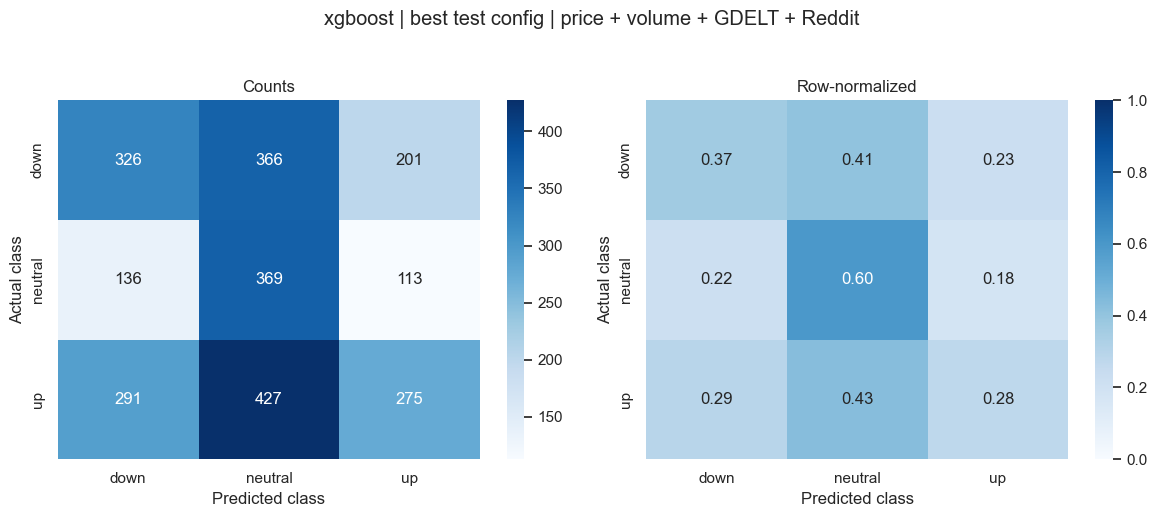

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\xgboost__best_test_config__price_plus_volume_plus_GDELT_plus_Reddit.png


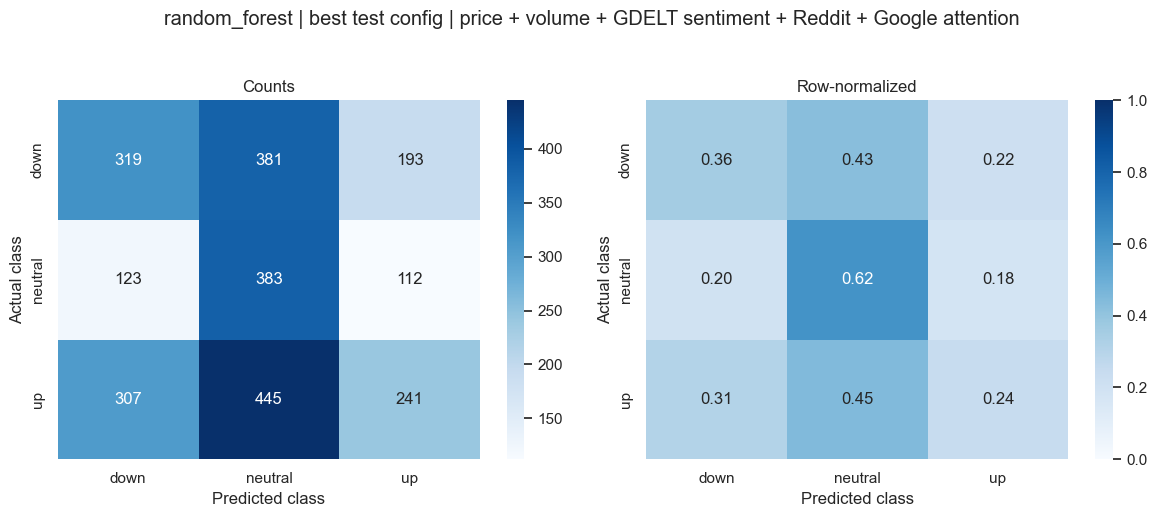

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\random_forest__best_test_config__price_plus_volume_plus_GDELT_sentiment_plus_Reddit_plus_Google_attention.png


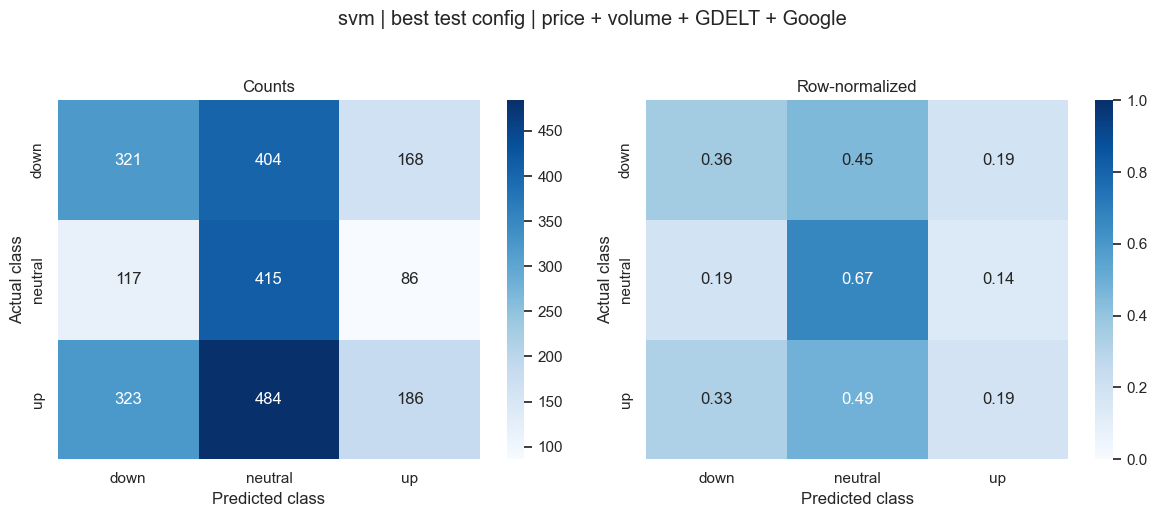

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\svm__best_test_config__price_plus_volume_plus_GDELT_plus_Google.png


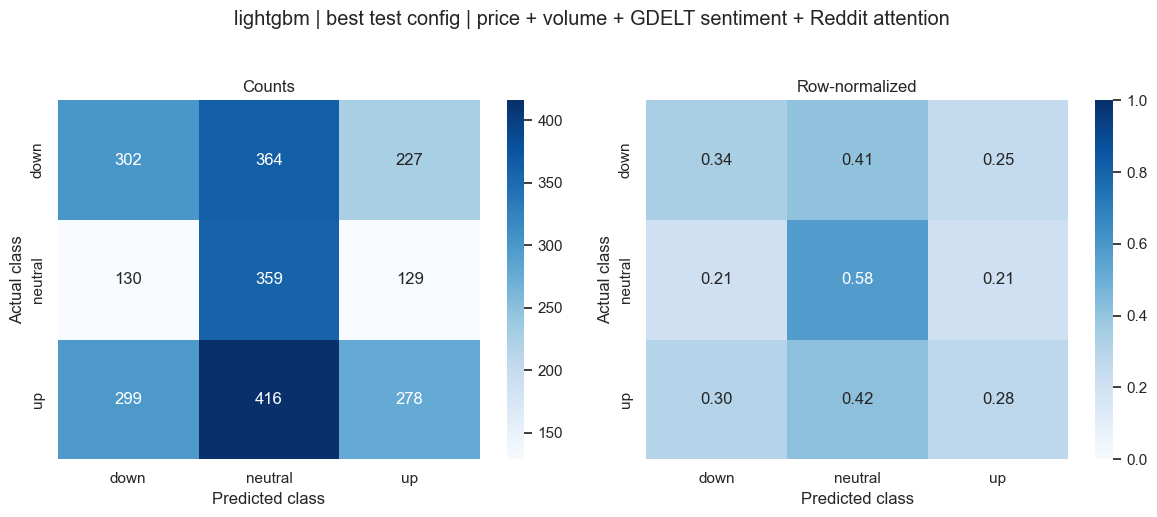

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\lightgbm__best_test_config__price_plus_volume_plus_GDELT_sentiment_plus_Reddit_attention.png


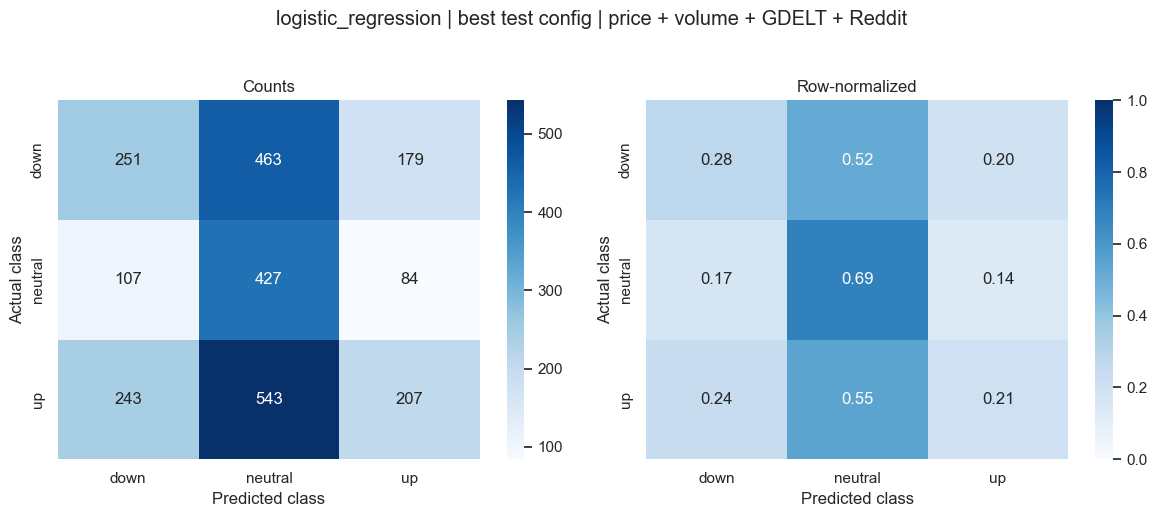

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\logistic_regression__best_test_config__price_plus_volume_plus_GDELT_plus_Reddit.png


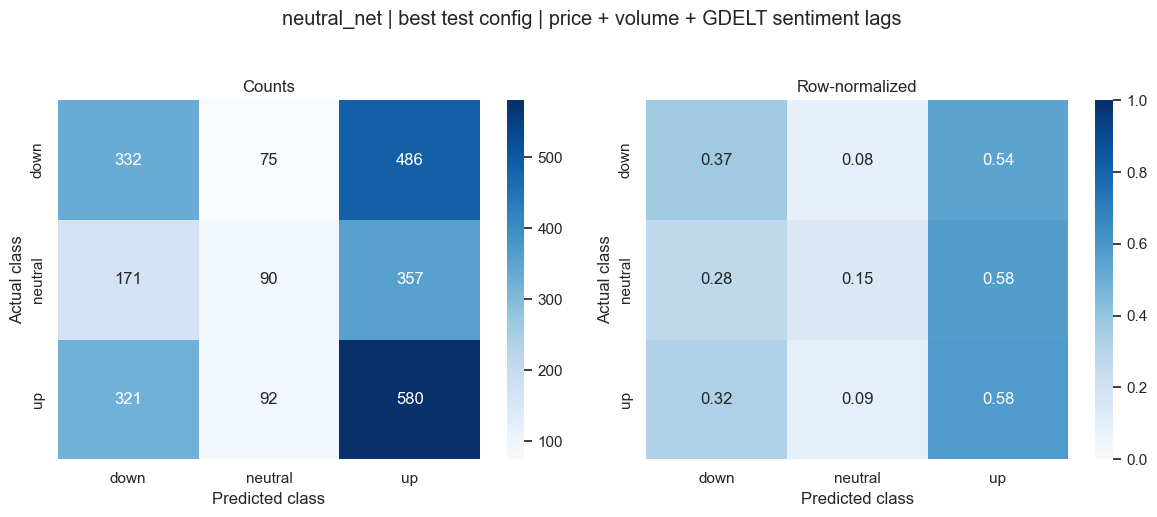

Saved: C:\Users\user\OneDrive\Documents\magisterka\praca magisterska\code\notebooks\outputs-three-classes-rich-price\test-diagnostics\confusion-matrices\neutral_net__best_test_config__price_plus_volume_plus_GDELT_sentiment_lags.png


In [12]:

def confusion_matrix_for_row(confusion_df: pd.DataFrame, row: pd.Series, *, normalized: bool = False) -> pd.DataFrame:
    subset = confusion_df[
        confusion_df["model_name"].eq(row["model_name"])
        & confusion_df["feature_set"].eq(row["feature_set"])
        & confusion_df["param_set"].eq(row["param_set"])
    ].copy()
    value_column = "row_normalized" if normalized else "count"
    return subset.pivot(
        index="actual_class_label",
        columns="predicted_class_label",
        values=value_column,
    ).reindex(index=["down", "neutral", "up"], columns=["down", "neutral", "up"])


def safe_filename(value: str) -> str:
    return (
        str(value)
        .replace(" ", "_")
        .replace("+", "plus")
        .replace("|", "")
        .replace("/", "_")
        .replace("\\", "_")
        .replace(":", "")
    )[:180]


plot_rows_df = best_by_model_df.drop_duplicates(["model_name", "feature_set", "param_set"])

for _, row in plot_rows_df.iterrows():
    matrix = confusion_matrix_for_row(best_confusion_matrices_df, row, normalized=False)
    matrix_norm = confusion_matrix_for_row(best_confusion_matrices_df, row, normalized=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(matrix, annot=True, fmt=".0f", cmap="Blues", ax=axes[0])
    axes[0].set_title("Counts")
    axes[0].set_xlabel("Predicted class")
    axes[0].set_ylabel("Actual class")

    sns.heatmap(matrix_norm, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, ax=axes[1])
    axes[1].set_title("Row-normalized")
    axes[1].set_xlabel("Predicted class")
    axes[1].set_ylabel("Actual class")

    title = f"{row['model_name']} | best test config | {row['feature_family']}"
    fig.suptitle(title, y=1.03)
    plt.tight_layout()

    plot_path = CONFUSION_PLOT_DIR / f"{safe_filename(row['model_name'])}__best_test_config__{safe_filename(row['feature_family'])}.png"
    fig.savefig(plot_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {plot_path}")



## Files to use in section 3.5

Recommended outputs after running this notebook from the top:

- `final_test_metrics_full.csv`: one best test configuration per model, selected by `test_balanced_accuracy` from each `*_final_test_verification.csv`,
- `final_test_metrics_vs_price_volume.csv`: the same best configurations with metric changes versus the model's `price + volume` baseline,
- `final_test_per_class_metrics.csv`: precision, recall and F1 by class for the best configuration of each model,
- `final_test_confusion_matrices.csv`: confusion-matrix values only for the best configuration of each model,
- PNG files in `confusion-matrices/`: confusion-matrix figures only for the best configuration of each model.

The `price + volume` rows are fitted internally only to compute the baseline deltas. They are not exported as final model rows.
